# 04 Index Calculation

Purpose: explain standardization, YEOI weights, yearly rankings, and sensitivity checks.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
scores = pd.read_csv(ROOT / 'data' / 'processed' / 'yeoi_scores.csv')
panel = pd.read_csv(ROOT / 'data' / 'raw' / 'city_panel.csv')
print(f'Scores shape: {scores.shape}')
print(f'YEOI complete: {scores["yeoi_score"].notna().sum()}/{len(scores)}')
print(f'Score columns: {[c for c in scores.columns if c.endswith("_score")]}')

Scores shape: (100, 13)
YEOI complete: 100/100
Score columns: ['job_opportunity_score', 'starting_income_score', 'living_cost_score', 'enterprise_opportunity_score', 'growth_potential_score', 'city_base_score', 'yeoi_score']


## 1. YEOI Formula

$$\text{YEOI} = 0.20 \times S_{\text{job}} + 0.20 \times S_{\text{income}} + 0.20 \times S_{\text{living}} + 0.20 \times S_{\text{enterprise}} + 0.10 \times S_{\text{growth}} + 0.10 \times S_{\text{base}}$$

| Sub-score | Weight | Primary metric | Fallback | Inverted |
|-----------|--------|---------------|----------|----------|
| `job_opportunity_score` | 0.20 | `job_posting_count` | `innovation_index`, `population_growth` | No |
| `starting_income_score` | 0.20 | `entry_salary` | `disposable_income` | No |
| `living_cost_score` | 0.20 | `rent_burden` | `housing_burden` | Yes (higher = less burden) |
| `enterprise_opportunity_score` | 0.20 | `listed_company_count` + `high_tech_company_count` (composite) | `listed_company_count` only | No |
| `growth_potential_score` | 0.10 | — | `population_growth` + `innovation_index` (mean) | No |
| `city_base_score` | 0.10 | — | `weighted_university_score` + `gdp_per_capita` (mean) | No |

- All components are **min-max standardized to 0–100 within each year**
- `living_cost_score` is **inverted** (higher score = lower cost = better)
- `enterprise_opportunity_score` uses **composite scoring**: both `listed_company_count` and `high_tech_company_count` are independently min-max normalized and then averaged
- Missing components → YEOI set to NaN (no imputation)

## 2. Yearly Rankings

Top 10 cities per year.

In [3]:
for year in sorted(scores['year'].unique()):
    year_data = scores[scores['year'] == year].dropna(subset=['rank']).sort_values('rank')
    print(f'\n=== {year} Top 10 ===')
    display(year_data[['rank', 'city', 'yeoi_score', 'job_opportunity_score',
                        'starting_income_score', 'living_cost_score', 'enterprise_opportunity_score',
                        'growth_potential_score', 'city_base_score']].head(10))


=== 2021 Top 10 ===


,rank,city,yeoi_score,job_opportunity_score,starting_income_score,living_cost_score,enterprise_opportunity_score,growth_potential_score,city_base_score
0,1,Beijing,71.282412,82.467154,99.757097,0.000000,100.000000,48.375620,100.000000
12,2,Shanghai,70.482189,100.000000,100.000000,13.224074,79.935596,48.758029,69.744525
14,3,Shenzhen,56.963374,46.780556,84.590861,19.169363,81.853995,58.900459,45.943729
4,4,Guangzhou,51.686441,36.376111,70.864329,70.276373,33.446209,40.411841,54.526524
15,5,Suzhou,48.799329,25.042023,54.969384,83.703956,42.820749,24.171564,50.749504
16,6,Wuhan,46.972766,25.487976,42.543394,82.726672,23.440957,68.632752,52.696914
5,7,Hangzhou,46.806571,26.300985,57.950003,69.613234,40.308175,35.110918,44.609994
10,8,Nanjing,44.983352,25.042023,57.481909,78.591676,21.207662,21.280007,63.906972
1,9,Changsha,40.610144,25.309595,30.843581,100.000000,13.190145,23.622633,43.792165
2,10,Chengdu,37.606847,25.309595,45.278579,62.793858,22.758874,34.796358,28.990298



=== 2022 Top 10 ===


,rank,city,yeoi_score,job_opportunity_score,starting_income_score,living_cost_score,enterprise_opportunity_score,growth_potential_score,city_base_score
20,1,Beijing,72.226214,82.466171,99.758359,0.000000,100.000000,57.813075,100.000000
32,2,Shanghai,71.592382,100.000000,100.000000,11.417029,84.993734,52.852696,70.249597
34,3,Shenzhen,58.563255,46.779112,84.591606,18.211243,85.009398,68.944178,47.505655
24,4,Guangzhou,52.153741,36.373166,70.863811,69.661230,35.401003,42.704089,54.234900
35,5,Suzhou,51.047025,25.042882,54.969958,83.375980,44.188596,43.234364,52.081049
25,6,Hangzhou,50.117366,26.300743,57.950192,69.456181,43.170426,63.285040,44.133531
30,7,Nanjing,47.129636,25.042882,57.482149,78.744470,21.710526,41.869931,63.466375
36,8,Wuhan,45.637446,25.485992,42.543974,83.726684,26.723058,46.957686,52.457360
21,9,Changsha,44.259739,25.309701,30.845089,100.000000,13.721805,58.466223,44.377975
22,10,Chengdu,40.527645,25.309701,45.278213,63.638515,29.072682,48.678774,29.999455



=== 2023 Top 10 ===


,rank,city,yeoi_score,job_opportunity_score,starting_income_score,living_cost_score,enterprise_opportunity_score,growth_potential_score,city_base_score
52,1,Shanghai,73.375483,100.000000,100.000000,12.906372,86.383870,64.904024,70.270320
40,2,Beijing,70.655563,82.477932,93.016480,0.000000,100.000000,55.566807,100.000000
54,3,Shenzhen,58.312068,46.815371,83.443493,18.675640,87.691477,61.536969,48.331752
44,4,Guangzhou,51.246102,36.328559,61.640649,69.884462,36.367505,49.712564,54.306104
55,5,Suzhou,49.866512,25.022464,51.908945,83.787351,47.028640,32.893522,50.276804
45,6,Hangzhou,48.622499,26.280459,59.751272,69.889838,48.432181,33.104807,44.412683
50,7,Nanjing,44.548435,25.022464,54.385355,78.933633,22.378240,22.358518,61.686451
56,8,Wuhan,42.717703,25.302606,39.661695,78.810166,30.119141,26.635156,52.754658
41,9,Changsha,41.401233,25.191606,28.129756,100.000000,14.424588,35.654046,42.866381
42,10,Chengdu,39.285724,25.191606,42.355525,64.978011,31.619436,34.268697,30.299391



=== 2024 Top 10 ===


,rank,city,yeoi_score,job_opportunity_score,starting_income_score,living_cost_score,enterprise_opportunity_score,growth_potential_score,city_base_score
72,1,Shanghai,72.152797,100.000,100.000000,13.285651,87.147842,50.000000,70.660981
60,2,Beijing,70.809938,82.500,98.029716,0.000000,100.000000,47.039950,100.000000
74,3,Shenzhen,64.088955,46.875,95.607235,21.336175,88.385997,93.154372,43.326361
65,4,Hangzhou,54.917674,26.250,68.378553,74.117804,49.522986,70.840603,41.797452
64,5,Guangzhou,54.538543,36.250,75.678295,73.748035,36.627609,52.166809,48.610740
75,6,Suzhou,51.559045,25.000,57.235142,89.479142,49.336503,26.512418,46.976458
70,7,Nanjing,47.855925,25.000,60.206718,83.981998,22.863043,37.165039,57.290689
76,8,Wuhan,45.436991,25.000,45.058140,84.135897,31.840216,32.923227,49.378178
61,9,Changsha,42.075851,25.000,31.944444,100.000000,15.011525,36.917545,39.929021
62,10,Chengdu,41.363515,25.000,49.903101,67.159114,31.803048,37.276855,28.627772



=== 2025 Top 10 ===


,rank,city,yeoi_score,job_opportunity_score,starting_income_score,living_cost_score,enterprise_opportunity_score,growth_potential_score,city_base_score
92,1,Shanghai,72.463604,100.000000,100.000000,12.291492,87.279124,54.737294,70.757516
80,2,Beijing,70.303211,82.503712,98.027960,0.000000,100.000000,41.968763,100.000000
94,3,Shenzhen,61.039215,46.884886,95.605482,20.760470,88.112931,64.817644,42.846968
84,4,Guangzhou,50.887128,36.232165,75.676344,62.550673,37.034583,38.203904,47.679850
85,5,Hangzhou,50.306416,26.244432,68.378698,70.131869,49.864319,32.049434,41.776095
95,6,Suzhou,50.297449,24.991930,57.233102,84.694020,49.820933,23.299357,46.195161
90,7,Nanjing,45.413760,24.991930,60.204894,79.367940,23.054714,21.696401,57.202239
96,8,Wuhan,43.563548,24.946736,45.057541,79.990738,32.517670,21.240051,49.370063
81,9,Changsha,40.839230,24.966105,31.942652,100.000000,15.628550,24.316774,39.000914
82,10,Chengdu,38.564501,24.966105,49.902497,63.705567,32.210021,15.116052,28.960576


## 3. Score Breakdown: Top vs Bottom Cities

Radar-style visualization of sub-scores.

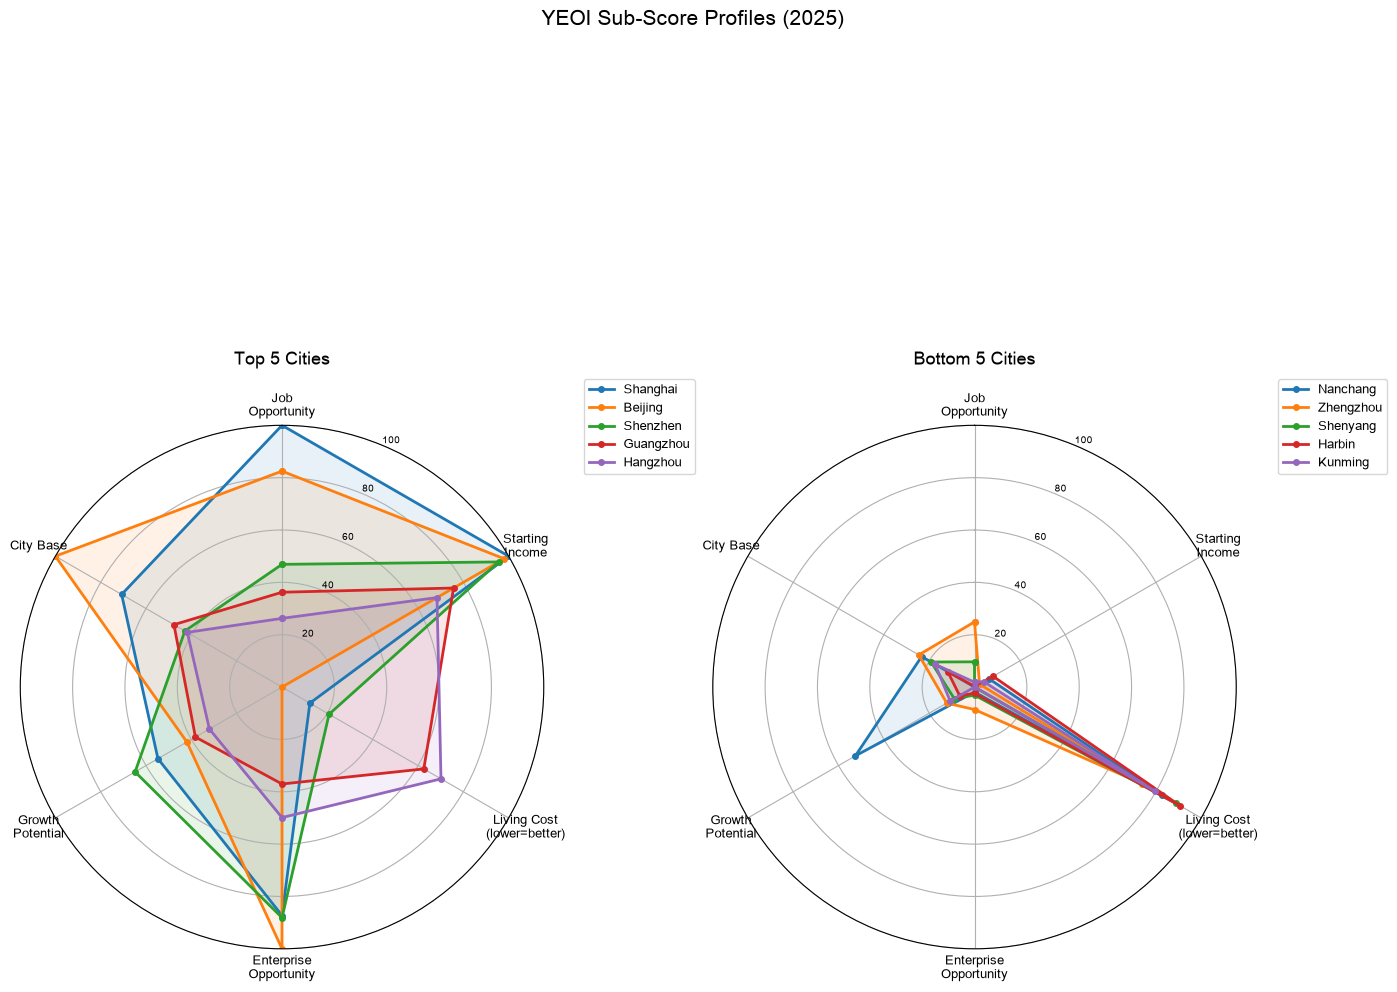

In [4]:
latest = scores[(scores['year'] == scores['year'].max()) & scores['yeoi_score'].notna()]
latest = latest.sort_values('yeoi_score', ascending=False)
top5 = latest.head(5)
bottom5 = latest.tail(5)

components = ['job_opportunity_score', 'starting_income_score', 'living_cost_score',
              'enterprise_opportunity_score', 'growth_potential_score', 'city_base_score']
comp_labels = ['Job\nOpportunity', 'Starting\nIncome', 'Living Cost\n(lower=better)',
               'Enterprise\nOpportunity', 'Growth\nPotential', 'City Base']

fig, axes = plt.subplots(1, 2, figsize=(14, 12), subplot_kw=dict(polar=True))

for ax, title, subset in [(axes[0], 'Top 5 Cities', top5), (axes[1], 'Bottom 5 Cities', bottom5)]:
    angles = np.linspace(0, 2 * np.pi, len(components), endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(comp_labels, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7)

    for _, row in subset.iterrows():
        values = [row[c] for c in components]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['city'], markersize=4)
        ax.fill(angles, values, alpha=0.1)
    ax.set_title(title, fontsize=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.suptitle(f'YEOI Sub-Score Profiles ({latest["year"].iloc[0]:.0f})', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

## 4. Weight Sensitivity Analysis

How stable are rankings when we shift weights? We track **max rank change** and **Spearman ρ** (vs baseline ranking).

- **Job opportunity weight (0.15–0.35):** weight is swapped with starting_income; other weights fixed
- **Living cost weight (0.10–0.30):** contrast scenario where other weights scale proportionally

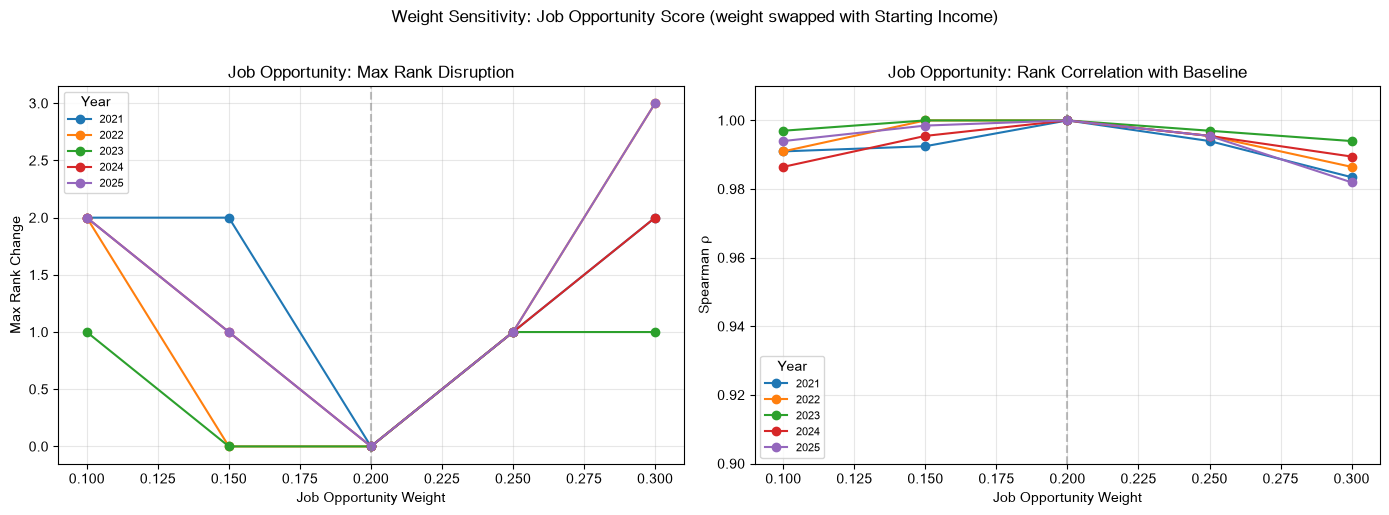

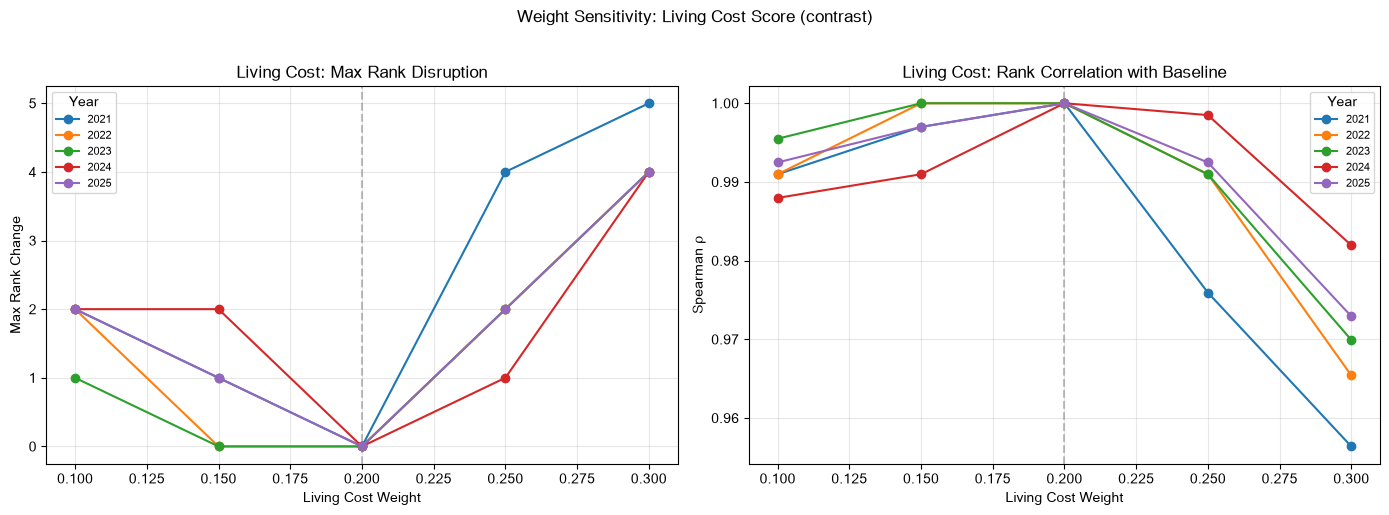

Job opportunity weight sensitivity (0.10→0.30, swapped with starting income):
  Max rank change: 3 positions
  Min Spearman ρ:  0.982
  Cities with >1 position change (worst case): 4

Living cost weight sensitivity (0.10→0.30, others scaled proportionally):
  Max rank change: 5 positions
  Min Spearman ρ:  0.956
  Cities with >2 position change (worst case): 6 year-weight combos


In [5]:
from scipy.stats import spearmanr

BASE_WEIGHTS = {
    'job_opportunity_score': 0.20, 'starting_income_score': 0.20,
    'living_cost_score': 0.20, 'enterprise_opportunity_score': 0.20,
    'growth_potential_score': 0.10, 'city_base_score': 0.10,
}

def compute_yeoi(df, weights):
    return sum(df[c] * w for c, w in weights.items())

def job_income_swap_weights(job_weight):
    weights = dict(BASE_WEIGHTS)
    weights['job_opportunity_score'] = job_weight
    fixed = sum(BASE_WEIGHTS[k] for k in weights if k not in ('job_opportunity_score', 'starting_income_score'))
    weights['starting_income_score'] = 1.0 - fixed - job_weight
    return weights

def proportional_weights(target_key, target_weight):
    remaining = 1.0 - target_weight
    other_keys = [k for k in BASE_WEIGHTS if k != target_key]
    other_base = sum(BASE_WEIGHTS[k] for k in other_keys)
    weights = {target_key: target_weight}
    for key in other_keys:
        weights[key] = BASE_WEIGHTS[key] / other_base * remaining
    return weights

def sensitivity_metrics(base_ranks, alt_ranks):
    base_order = {city: i for i, city in enumerate(base_ranks)}
    alt_order = {city: i for i, city in enumerate(alt_ranks)}
    changes = [abs(base_order[city] - alt_order[city]) for city in base_ranks]
    rho, _ = spearmanr(list(base_order.values()), [alt_order[city] for city in base_ranks])
    return {
        'max_rank_change': max(changes),
        'cities_gt1': sum(change > 1 for change in changes),
        'spearman_rho': rho,
    }

def run_sensitivity(weight_fn, param_values, param_name):
    rows = []
    for year, group in latest_valid.groupby('year'):
        base_ranks = group.sort_values('yeoi_score', ascending=False)['city'].tolist()
        for value in param_values:
            weights = weight_fn(value)
            group_alt = group.copy()
            group_alt['alt_yeoi'] = compute_yeoi(group_alt, weights)
            alt_ranks = group_alt.sort_values('alt_yeoi', ascending=False)['city'].tolist()
            rows.append({'year': year, param_name: value, **sensitivity_metrics(base_ranks, alt_ranks)})
    return pd.DataFrame(rows)

latest_valid = scores[scores['yeoi_score'].notna()].copy()
job_weights = np.arange(0.10, 0.35, 0.05)
living_weights = np.arange(0.10, 0.35, 0.05)

job_sens = run_sensitivity(job_income_swap_weights, job_weights, 'job_weight')
living_sens = run_sensitivity(
    lambda lw: proportional_weights('living_cost_score', lw),
    living_weights,
    'living_weight',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
job_sens.pivot(index='job_weight', columns='year', values='max_rank_change').plot(
    marker='o', ax=axes[0]
)
axes[0].axvline(x=0.20, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Job Opportunity Weight')
axes[0].set_ylabel('Max Rank Change')
axes[0].set_title('Job Opportunity: Max Rank Disruption')
axes[0].legend(title='Year', fontsize=8)
axes[0].grid(True, alpha=0.3)

job_sens.pivot(index='job_weight', columns='year', values='spearman_rho').plot(
    marker='o', ax=axes[1]
)
axes[1].axvline(x=0.20, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Job Opportunity Weight')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Job Opportunity: Rank Correlation with Baseline')
axes[1].set_ylim(0.9, 1.01)
axes[1].legend(title='Year', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.suptitle('Weight Sensitivity: Job Opportunity Score (weight swapped with Starting Income)', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
living_sens.pivot(index='living_weight', columns='year', values='max_rank_change').plot(
    marker='o', ax=axes[0]
)
axes[0].axvline(x=0.20, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Living Cost Weight')
axes[0].set_ylabel('Max Rank Change')
axes[0].set_title('Living Cost: Max Rank Disruption')
axes[0].legend(title='Year', fontsize=8)
axes[0].grid(True, alpha=0.3)

living_sens.pivot(index='living_weight', columns='year', values='spearman_rho').plot(
    marker='o', ax=axes[1]
)
axes[1].axvline(x=0.20, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Living Cost Weight')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Living Cost: Rank Correlation with Baseline')
axes[1].legend(title='Year', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.suptitle('Weight Sensitivity: Living Cost Score (contrast)', y=1.02)
plt.tight_layout()
plt.show()

print('Job opportunity weight sensitivity (0.10→0.30, swapped with starting income):')
print(f'  Max rank change: {job_sens["max_rank_change"].max():.0f} positions')
print(f'  Min Spearman ρ:  {job_sens["spearman_rho"].min():.3f}')
print(f'  Cities with >1 position change (worst case): {job_sens["cities_gt1"].max():.0f}')
print()
print('Living cost weight sensitivity (0.10→0.30, others scaled proportionally):')
print(f'  Max rank change: {living_sens["max_rank_change"].max():.0f} positions')
print(f'  Min Spearman ρ:  {living_sens["spearman_rho"].min():.3f}')
print(f'  Cities with >2 position change (worst case): {(living_sens["max_rank_change"] > 2).sum()} year-weight combos')

## 5. Living Cost Inversion Check

Verify that `living_cost_score` is correctly inverted: higher score = lower cost = better.

In [ ]:
# Check: city with highest rent_burden should have lowest living_cost_score
for yr in sorted(panel['year'].unique())[-3:]:
    yr_panel = panel[panel['year'] == yr].dropna(subset=['rent_burden'])
    yr_scores = scores[scores['year'] == yr].dropna(subset=['living_cost_score'])
    merged = yr_panel.merge(yr_scores[['city', 'year', 'living_cost_score']], on=['city', 'year'])
    max_burden_city = merged.loc[merged['rent_burden'].idxmax()]
    min_burden_city = merged.loc[merged['rent_burden'].idxmin()]
    print(f'{yr}: Highest rent burden = {max_burden_city["city"]} ({max_burden_city["rent_burden"]:.4f}, score={max_burden_city["living_cost_score"]:.1f})')
    print(f'       Lowest rent burden  = {min_burden_city["city"]} ({min_burden_city["rent_burden"]:.4f}, score={min_burden_city["living_cost_score"]:.1f})')
    if max_burden_city['living_cost_score'] < min_burden_city['living_cost_score']:
        print('       ✅ Inversion correct: higher burden → lower score')
    else:
        print('       ❌ Inversion FAILED')

## 6. YEOI Score Components Weights

Visualize the weight contribution for the top-ranked city.

In [ ]:
top_city = latest.head(1).iloc[0]
contributions = {c: top_city[c] * w for c, w in BASE_WEIGHTS.items()}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(list(contributions.keys()), list(contributions.values()),
              color=['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628'],
              edgecolor='white')
ax.axhline(y=top_city['yeoi_score'], color='darkred', linestyle='--', alpha=0.5,
           label=f'Total YEOI = {top_city["yeoi_score"]:.1f}')
ax.set_title(f'YEOI Component Contributions: {top_city["city"]} ({top_city["year"]:.0f})')
ax.set_ylabel('Weighted Score')
ax.set_xticklabels([c.replace('_score', '').replace('_', '\n') for c in contributions.keys()],
                   fontsize=8)
ax.legend()

for bar, (comp, val) in zip(bars, contributions.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()